In [10]:
%pip install numpy 
%pip install pandas 
%pip install scipy 
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.cm as cm
import soundfile as sf
import seaborn as sns
from scipy.io import wavfile
from scipy.signal import stft
from scipy.stats import entropy, gmean, kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding

# 1. Loading the files and creating a data frame

In [12]:
# - Durchsucht Unterordner Z01 und Z05 jeweils in deren Wav-Unterordner
pattern = os.path.join('*Datei', 'sig', 'Z*', 'Z*', 'Z*', 'Wav', '*.wav')

# Alle Dateien finden, die dem Muster entsprechen
files = glob.glob(pattern)
print(len(files), 'files', '\n', files[264])  # Print for Error-Checks

440 files 
 Seminaraufgabe_2_Datei\sig\Z03\Z03_Pos06_RC2_75k_0000\Z03_Pos06_RC2_75k_0000_1307031507\Wav\Z03_Pos06_RC2_75k_0000_1307031507_00000_14_Ch1.wav


In [32]:
data = []

# Durchläuft alle gefundenen Dateien
for fn in files:
    try:
        # fs = Abtastrate (Sampling Frequency)
        signal, fs = sf.read(fn)
    except Exception as e:
        # Print for Error
        print(f"Fehler beim Lesen von {fn}: {e}")
        continue  # Überspringt fehlerhafte Datei

    # Extrahiert Dateinamen
    basename = os.path.basename(fn)
    parts = basename.split('_')
    
    if len(parts) < 9:
        print("Unvollständiger Dateiname:", basename)
        continue  # Überspringen, wenn parts zu kurz ist

    sID = parts[8][:-4].strip()

    # Erstellt Datensatz mit Metadaten und Signal (Keys der Aufgabenstellung entsprechend)
    entry = {
        'fn': basename,         
        'sig': signal,     
        'spec': parts[0],  
        'mID': parts[4],   
        'time': parts[5],  
        'rID': parts[6],     
        'sID': parts[8][:-4],  
        'stft': None       
    }
    
    data.append(entry)  # Fügt Datensatz zur Liste hinzu

# Erstellt DataFrame aus der Liste
df = pd.DataFrame(data)
    
print(df['sID'].value_counts())

DataFrame-Übersicht:
                                                  fn  \
0  Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch1...   
1  Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...   
2  Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch1...   
3  Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...   
4  Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch1...   

                                                 sig spec   mID        time  \
0  [0.00048828125, 0.00244140625, 0.0029296875, 0...  Z01  0000  1307031427   
1  [0.001953125, 0.0, 0.00146484375, 0.001953125,...  Z01  0000  1307031427   
2  [0.00146484375, 0.0, 0.00048828125, 0.00195312...  Z01  0000  1307031427   
3  [-0.00048828125, 0.0009765625, 0.0, -0.0009765...  Z01  0000  1307031427   
4  [0.00048828125, 0.00146484375, 0.00048828125, ...  Z01  0001  1312091511   

     rID  sID  stft  
0  00000  Ch1  None  
1  00000  Ch2  None  
2  00001  Ch1  None  
3  00001  Ch2  None  
4  00000  Ch1  None  
Anzahl der gefundenen Ch2-Dateien: 

# 2. Separate channels

In [38]:
df['sID'] = df['sID'].astype(str).str.strip()
df_ch1 = df[df['sID'] == 'Ch1'].copy()
df_ch2 = df[df['sID'] == 'Ch2'].copy()

merge_keys = ['spec', 'mID', 'time', 'rID']

df_merged = pd.merge(
    df_ch1[['spec', 'mID', 'time', 'rID', 'sig']],
    df_ch2[['spec', 'mID', 'time', 'rID', 'sig']],
    on=merge_keys,
    suffixes=('_ch1', '_ch2')
)

# print("Gesamtbeispiele:", len(df_merged))
display(df_merged.head())
print(df_ch2)

print("Ch1:", df_ch1[merge_keys].shape[0])
print("Ch2:", df_ch2[merge_keys].shape[0])
print("df_merged", df_merged.columns)

,spec,mID,time,rID,sig_ch1,sig_ch2
0,Z01,0000,1307031427,00000,"[0.00048828125, 0.00244140625, 0.0029296875, 0...","[0.001953125, 0.0, 0.00146484375, 0.001953125,..."
1,Z01,0000,1307031427,00001,"[0.00146484375, 0.0, 0.00048828125, 0.00195312...","[-0.00048828125, 0.0009765625, 0.0, -0.0009765..."
2,Z01,0001,1312091511,00000,"[0.00048828125, 0.00146484375, 0.00048828125, ...","[0.00048828125, 0.0009765625, 0.001953125, 0.0..."
3,Z01,0001,1312091511,00001,"[0.00146484375, 0.0009765625, 0.0, 0.0, 0.0009...","[0.00048828125, 0.0, 0.0009765625, 0.000976562..."
4,Z01,0002,1312101402,00000,"[0.0, 0.00048828125, 0.0, -0.00048828125, 0.00...","[0.00048828125, -0.0009765625, 0.0, 0.00097656..."


                                                    fn  \
1    Z01_Pos00_RC2_75k_0000_1307031427_00000_14_Ch2...   
3    Z01_Pos00_RC2_75k_0000_1307031427_00001_14_Ch2...   
5    Z01_Pos00_RC2_75k_0001_1312091511_00000_14_Ch2...   
7    Z01_Pos00_RC2_75k_0001_1312091511_00001_14_Ch2...   
9    Z01_Pos00_RC2_75k_0002_1312101402_00000_14_Ch2...   
..                                                 ...   
431  Z05_Pos07_RC2_75k_0000_1307031539_00001_14_Ch2...   
433  Z05_Pos08_RC2_75k_0000_1307031539_00000_14_Ch2...   
435  Z05_Pos08_RC2_75k_0000_1307031539_00001_14_Ch2...   
437  Z05_Pos09_RC2_75k_0000_1307031540_00000_14_Ch2...   
439  Z05_Pos09_RC2_75k_0000_1307031540_00001_14_Ch2...   

                                                   sig spec   mID        time  \
1    [0.001953125, 0.0, 0.00146484375, 0.001953125,...  Z01  0000  1307031427   
3    [-0.00048828125, 0.0009765625, 0.0, -0.0009765...  Z01  0000  1307031427   
5    [0.00048828125, 0.0009765625, 0.001953125, 0.0...  Z01 

# 3. Feature extraction

In [42]:
def compute_stft(sig, fs=1041667):
    f, t, Zxx = stft(sig, fs=fs, nperseg=1024)
    return (f, t, Zxx)

def extract_all_features(sig, stft, suffix=''):
    # zeitliche Merkmale
    signal_mean, signal_var, signal_skew, signal_rms, signal_peak, signal_kurtosis = analyze_signal(sig)
    # Spektralmerkmale
    spectral_mean, spectral_var, entropy_up, flatness, rolloff, kurt_up = analyze_stft(stft)

    return {
        f'sig_mean{suffix}': signal_mean,
        f'sig_var{suffix}': signal_var,
        f'sig_skew{suffix}': signal_skew,
        f'sig_rms{suffix}': signal_rms,
        f'sig_peak{suffix}': signal_peak,
        f'sig_kurtosis{suffix}': signal_kurtosis,
        f'spec_mean{suffix}': spectral_mean,
        f'spec_var{suffix}': spectral_var,
        f'spec_entropy_up{suffix}': entropy_up,
        f'spec_flatness{suffix}': flatness,
        f'spec_rolloff_freq{suffix}': rolloff,
        f'spec_kurtosis{suffix}': kurt_up
    }

def analyze_stft(stft):
    magnitude = np.abs(stft[2])
    mag_mean = np.mean(magnitude, axis=1)  # magnitude averaged by time
    spectral_mean = np.sum(stft[0] * mag_mean) / np.sum(mag_mean) # average frequency, weighted by magnitude
    spectral_variance = np.sum(((stft[0] - spectral_mean) ** 2) * mag_mean) / np.sum(mag_mean) #distance of each frequency bin from the mean
    upper_half = mag_mean[len(stft[0])//2:]
    prob_dist = upper_half / np.sum(upper_half)
    entropy_upper = entropy(prob_dist) # how irregular the upper part of the spectrum is
    flatness = gmean(upper_half + 1e-8) / np.mean(upper_half) # how much noise there is
    cumulative_energy = np.cumsum(mag_mean)
    rolloff_idx = np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])
    rolloff_freq = stft[0][rolloff_idx]  # 85% of energy is below this frequency
    kurt_upper = kurtosis(upper_half) # reflects spikiness or asymmetry in the upper band
    
    return spectral_mean, spectral_variance, entropy_upper, flatness, rolloff_freq, kurt_upper


def analyze_signal(sig):
    signal_mean = np.mean(sig)
    signal_variance = np.var(sig)
    signal_skewness = skew(sig)
    signal_kurtosis = kurtosis(sig)  # fourth moment
    signal_rms = np.sqrt(np.mean(sig**2))
    signal_peak = np.max(np.abs(sig))  # peak amplitude
    return signal_mean, signal_variance, signal_skewness, signal_rms, signal_peak, signal_kurtosis

In [43]:
featureslist = ['sig_mean', 'sig_var', 'sig_skew', 'sig_rms', 'sig_peak', 'sig_kurtosis' 'spec_mean', 'spec_var', 'spec_entropy_up', 'spec_flatness', 'spec_rolloff_freq', 'spec_kurtosis']  # added new features
for i in featureslist:
    df[i] = None

In [46]:
features = []

for idx, row in df_merged.iterrows():
    sig1 = row['sig_ch1']
    sig2 = row['sig_ch2']

    stft1 = compute_stft(sig1)
    stft2 = compute_stft(sig2)

    f1 = extract_all_features(sig1, stft1, suffix='_ch1')
    f2 = extract_all_features(sig2, stft2, suffix='_ch2')

    features.append({**row, **f1, **f2})
    
df_features = pd.DataFrame(features)
print(df_features.columns)

Index(['spec', 'mID', 'time', 'rID', 'sig_ch1', 'sig_ch2', 'sig_mean_ch1',
       'sig_var_ch1', 'sig_skew_ch1', 'sig_rms_ch1', 'sig_peak_ch1',
       'sig_kurtosis_ch1', 'spec_mean_ch1', 'spec_var_ch1',
       'spec_entropy_up_ch1', 'spec_flatness_ch1', 'spec_rolloff_freq_ch1',
       'spec_kurtosis_ch1', 'sig_mean_ch2', 'sig_var_ch2', 'sig_skew_ch2',
       'sig_rms_ch2', 'sig_peak_ch2', 'sig_kurtosis_ch2', 'spec_mean_ch2',
       'spec_var_ch2', 'spec_entropy_up_ch2', 'spec_flatness_ch2',
       'spec_rolloff_freq_ch2', 'spec_kurtosis_ch2'],
      dtype='object')


# 4. Feature Overview

## 4.1 Boxplot: comparison of characteristics between channels

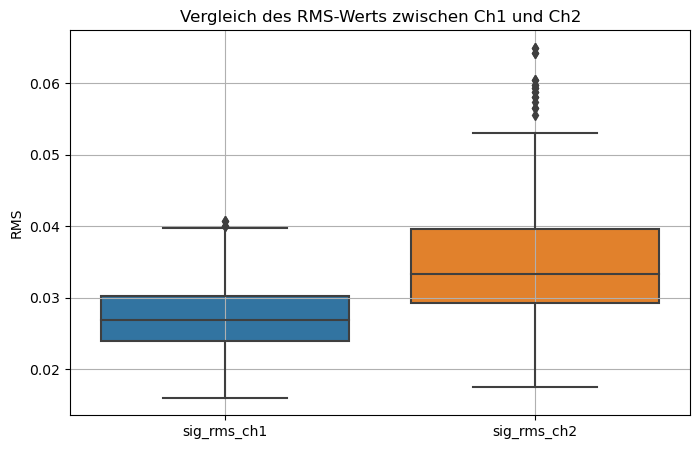

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_features[['sig_rms_ch1', 'sig_rms_ch2']])
plt.title('Vergleich des RMS-Werts zwischen Ch1 und Ch2')
plt.ylabel('RMS')
plt.grid()
plt.show()

## 4.2 Scatter Plot: comparison of two characteristics 
spectral_mean vs. spectral_flatness — one channel at a time.


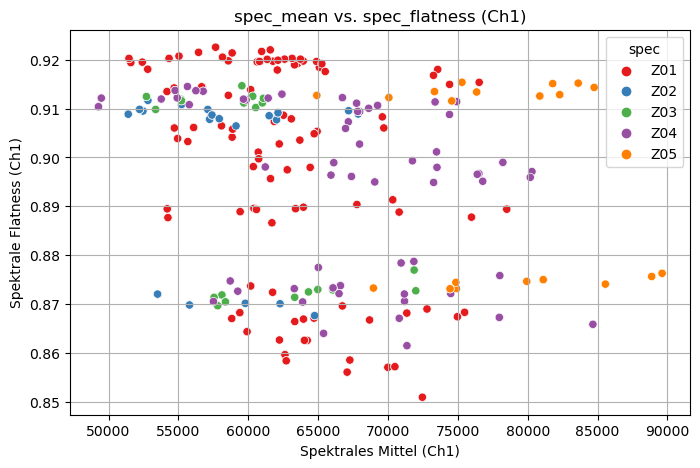

spec_mean_ch1        0
spec_flatness_ch1    0
dtype: int64


In [60]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_features,
    x='spec_mean_ch1', 
    y='spec_flatness_ch1', 
    hue='spec',  
    palette='Set1'
)
plt.title('spec_mean vs. spec_flatness (Ch1)')
plt.xlabel('Spektrales Mittel (Ch1)')
plt.ylabel('Spektrale Flatness (Ch1)')
plt.grid()
plt.show()

## 4.3 Histogram: distribution of a single characteristic

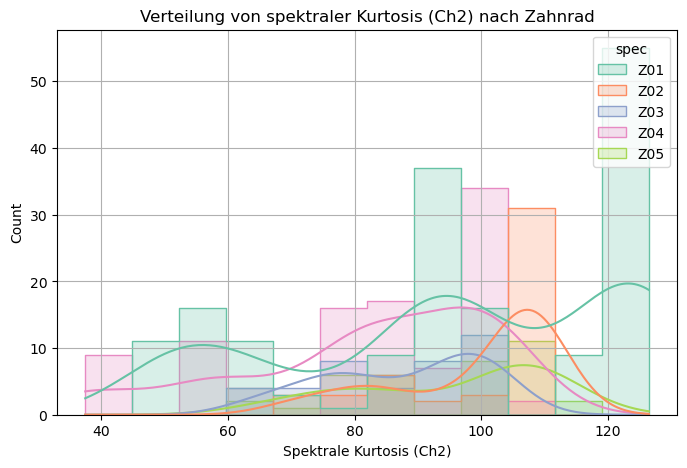

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_features, x='spec_kurtosis_ch2', hue='spec', kde=True, element='step', palette='Set2')
plt.title('Verteilung von spektraler Kurtosis (Ch2) nach Zahnrad')
plt.xlabel('Spektrale Kurtosis (Ch2)')
plt.grid()
plt.show()

## 4.4 Pairplot (Seaborn): clustering by characteristics

C:\Users\OsenD\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


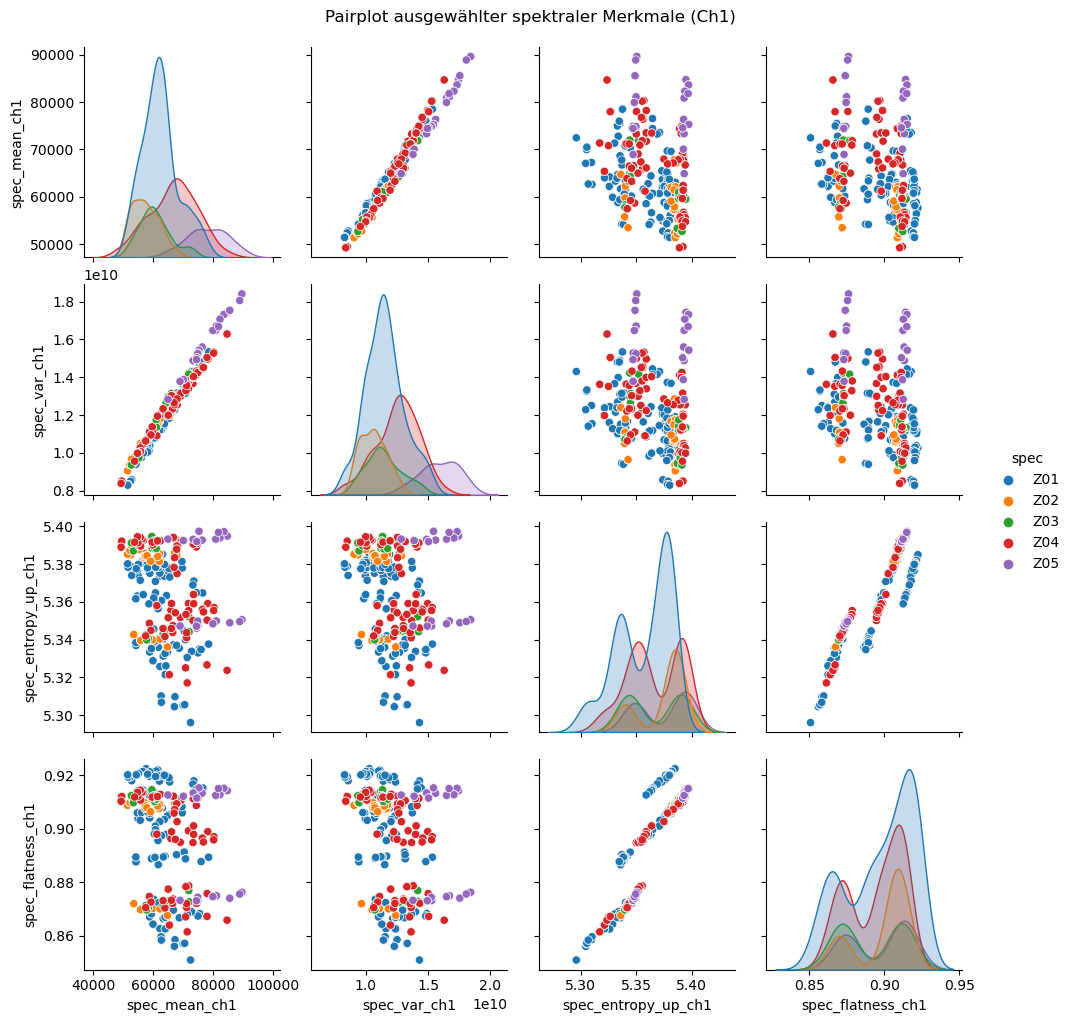

In [58]:
selected = ['spec_mean_ch1', 'spec_var_ch1', 'spec_entropy_up_ch1', 'spec_flatness_ch1']
sns.pairplot(df_features[selected + ['spec']], hue='spec', palette='tab10')
plt.suptitle('Pairplot ausgewählter spektraler Merkmale (Ch1)', y=1.02)
plt.show()